# Introduction to Machine Learning

## Overview

This week introduces the basic workflow of machine learning and applies two fundamental supervised learning algorithms:

1. Linear Regression for a regression problem.
2. Logistic Regression for a binary classification problem.

The standard machine learning workflow used in this notebook is:

**Split → Train → Predict → Evaluate**

## Learning Goals

By the end of this notebook, I will be able to:

- Understand the basic machine learning workflow.
- Split data into training and testing sets.
- Train a Linear Regression model.
- Make predictions using a trained model.
- Evaluate regression predictions using MAE, MSE, RMSE, and R².
- Train a Logistic Regression model.
- Evaluate a binary classification model using appropriate classification metrics.
- Compare the two machine learning approaches.
- Explain the results in plain language.


## 1.Import Required Libraries

We will use Pandas and NumPy for data handling, Matplotlib and Seaborn for visualization, and scikit-learn for machine learning models and evaluation metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Linear Regression

Linear Regression is a supervised machine learning algorithm used to predict a continuous numerical target.

The model attempts to learn the relationship between input features and a numerical target.

For this project, we will use the Diabetes dataset provided by scikit-learn.

### Load the Diabetes Dataset

The Diabetes dataset contains numerical features related to patients and a quantitative target variable.

We will use the features to predict the target value.

In [2]:
diabetes = load_diabetes()

X_reg = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

y_reg = pd.Series(
    diabetes.target,
    name="target"
)

print("Regression dataset loaded successfully!")
print("Features shape:", X_reg.shape)
print("Target shape:", y_reg.shape)

X_reg.head()

Regression dataset loaded successfully!
Features shape: (442, 10)
Target shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


### Explore the Regression Dataset

Before training the model, we inspect the dataset to understand its structure and check for missing values.

In [3]:
print("Dataset information:")
print(X_reg.info())

print("\nMissing values:")
print(X_reg.isnull().sum())

print("\nDescriptive statistics:")
X_reg.describe()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB
None

Missing values:
age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

Descriptive statistics:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


### Train-Test Split

We divide the data into training and testing sets.

- 80% of the data will be used for training.
- 20% will be used for testing.

The `random_state` is fixed so that the result is reproducible.

In [4]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train_reg.shape)
print("Testing features:", X_test_reg.shape)
print("Training target:", y_train_reg.shape)
print("Testing target:", y_test_reg.shape)

Training features: (353, 10)
Testing features: (89, 10)
Training target: (353,)
Testing target: (89,)


### Train the Linear Regression Model

We now create a Linear Regression model and train it using the training data.

In [5]:
linear_model = LinearRegression()

linear_model.fit(
    X_train_reg,
    y_train_reg
)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


### Make Predictions

After training, the model can be used to predict target values for the unseen test data.

In [6]:
y_pred_reg = linear_model.predict(X_test_reg)

print("First 10 predictions:")
print(y_pred_reg[:10])

First 10 predictions:
[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858]


### Regression Evaluation Metrics
We will evaluate the Linear Regression model using four metrics:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [7]:
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Regression Model Evaluation")
print("-" * 35)
print("MAE :", round(mae, 4))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

Regression Model Evaluation
-----------------------------------
MAE : 42.7941
MSE : 2900.1936
RMSE: 53.8534
R²  : 0.4526


### Actual vs Predicted Values

A scatter plot can help us compare the actual target values with the values predicted by the Linear Regression model.

If predictions were perfect, the points would lie close to the diagonal reference line.

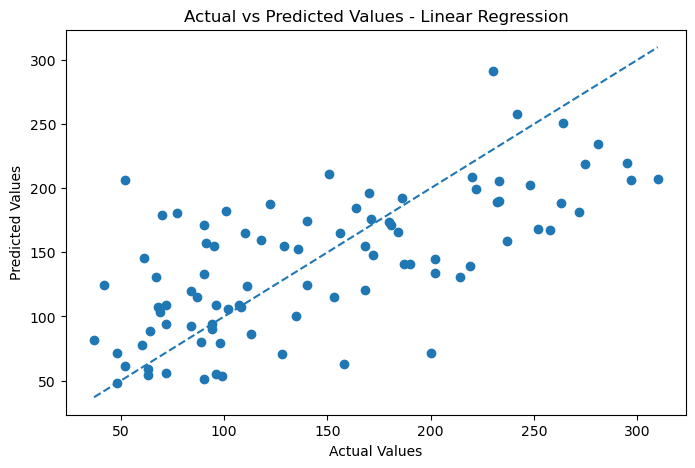

In [8]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test_reg, y_pred_reg)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values - Linear Regression")

min_value = min(y_test_reg.min(), y_pred_reg.min())
max_value = max(y_test_reg.max(), y_pred_reg.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.show()

### Regression Interpretation

The Linear Regression model was trained using 80% of the Diabetes dataset and evaluated on the remaining 20%.

MAE, MSE, and RMSE measure prediction error, while R² describes how much variation in the target is explained by the model.

The evaluation metrics provide a numerical way to understand how well the model performs on unseen test data.

The actual and predicted value plot provides a visual comparison between the model's predictions and the observed target values.

## 6. Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for classification problems.

Unlike Linear Regression, which predicts a continuous numerical value, Logistic Regression predicts the probability of belonging to a class.

For this project, we will use the Breast Cancer dataset provided by scikit-learn.

The target contains two classes, making this a binary classification problem.

### Load the Classification Dataset

The Breast Cancer dataset contains numerical measurements and a binary target indicating the class of each observation.

In [9]:
cancer = load_breast_cancer()

X_clf = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

y_clf = pd.Series(
    cancer.target,
    name="target"
)

print("Classification dataset loaded successfully!")
print("Features shape:", X_clf.shape)
print("Target shape:", y_clf.shape)

X_clf.head()

Classification dataset loaded successfully!
Features shape: (569, 30)
Target shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Explore the Classification Dataset

We check the structure of the data, missing values, and class distribution before training the model.

In [10]:
print("Missing values:")
print(X_clf.isnull().sum().sum())

print("\nClass distribution:")
print(y_clf.value_counts())

print("\nClass names:")
print(cancer.target_names)

Missing values:
0

Class distribution:
target
1    357
0    212
Name: count, dtype: int64

Class names:
['malignant' 'benign']


### Train-Test Split

We split the classification dataset into training and testing sets.

The `stratify` parameter helps preserve the class distribution in both sets.

In [11]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

print("Training features:", X_train_clf.shape)
print("Testing features:", X_test_clf.shape)

Training features: (455, 30)
Testing features: (114, 30)


### Train the Logistic Regression Model

We now train a Logistic Regression model using the training data.

In [12]:
logistic_model = LogisticRegression(
    max_iter=10000
)

logistic_model.fit(
    X_train_clf,
    y_train_clf
)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Make Predictions

The trained Logistic Regression model is used to predict the classes of the unseen test data.

In [13]:
y_pred_clf = logistic_model.predict(X_test_clf)

print("First 20 predictions:")
print(y_pred_clf[:20])

First 20 predictions:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


### Classification Evaluation

For the classification model, we will use:

- Accuracy
- Confusion matrix
- Precision
- Recall
- F1-score
  
Accuracy measures the proportion of predictions that were correct.
The confusion matrix shows the number of correct and incorrect predictions for each class.
Precision measures how many predicted positive cases were actually positive.
Recall measures how many actual positive cases were correctly identified.
The F1-score combines precision and recall into one metric.

In [14]:
accuracy = accuracy_score(y_test_clf, y_pred_clf)

print("Classification Model Evaluation")
print("-" * 35)
print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test_clf,
        y_pred_clf,
        target_names=cancer.target_names
    )
)

Classification Model Evaluation
-----------------------------------
Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



### Confusion Matrix

A confusion matrix shows how the classification model's predictions compare with the actual classes.

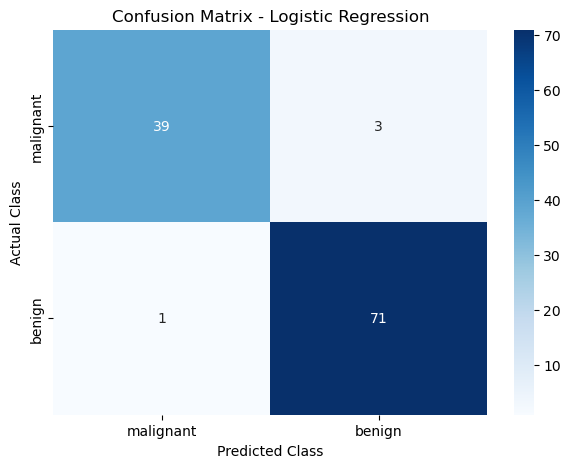

In [15]:
cm = confusion_matrix(
    y_test_clf,
    y_pred_clf
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=cancer.target_names,
    yticklabels=cancer.target_names
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

### Classification Interpretation

The Logistic Regression model was trained using the training portion of the dataset and evaluated using previously unseen test data.

Accuracy provides an overall measure of correct predictions, while precision, recall, and F1-score provide additional information about classification performance.

The confusion matrix helps identify how many observations were correctly and incorrectly classified in each class.

# 7. Model Comparison

The two projects use different types of machine learning problems like:
- Regression
- Binary Clasification 

The metrics are different because regression and classification solve different types of prediction problems.

Regression predicts numerical values, so prediction errors are measured using numerical error metrics.

Classification predicts categories, so performance is measured using classification metrics such as accuracy, precision, recall, and F1-score.

In [16]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Logistic Regression"
    ],
    "Problem Type": [
        "Regression",
        "Binary Classification"
    ],
    "Primary Metric": [
        f"R² = {r2:.4f}",
        f"Accuracy = {accuracy:.4f}"
    ]
})

comparison

,Model,Problem Type,Primary Metric
0,Linear Regression,Regression,R² = 0.4526
1,Logistic Regression,Binary Classification,Accuracy = 0.9649


## 9. Plain-Language Conclusion

Machine learning models learn patterns from existing data and use those patterns to make predictions on new data.

In this notebook, Linear Regression was used for predicting a numerical value, while Logistic Regression was used for predicting one of two classes.

The models were trained on training data and evaluated on separate test data. This separation helps us understand how the models perform on data that they did not directly use during training.

The evaluation metrics provide different ways to understand model performance. For regression, MAE, MSE, RMSE, and R² describe prediction errors and explained variation. For classification, accuracy, precision, recall, F1-score, and the confusion matrix describe classification performance.

The main lesson from this exercise is that the choice of model and evaluation metric depends on the type of prediction problem.

## 10. Completion Checklist

-  Explained the basic machine learning workflow
-  Explained train-test splitting
-  Loaded a regression dataset
-  Implemented Linear Regression
-  Generated regression predictions
   Calculated MAE
-  Calculated MSE
-  Calculated RMSE
-  Calculated R²
-  Created an actual vs predicted visualization
-  Loaded a binary classification dataset
-  Implemented Logistic Regression
-  Generated classification predictions
-  Calculated accuracy
-  Calculated precision
-  Calculated recall
-  Calculated F1-score
-  Created a confusion matrix
-  Compared regression and classification approaches
-  Explained the results in plain language
-  Added a final conclusion